## 1. load transition data

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from pprint import pprint

In [4]:
def load_replay_buffer_data(base_directory):
    """
    지정된 디렉토리 내의 replay_buffer 폴더에서 모든 .npz 파일을 불러옵니다.
    
    Args:
        base_directory (str): 기본 디렉토리 경로
    
    Returns:
        dict: 파일명을 키로, 불러온 데이터를 값으로 하는 딕셔너리
    """
    # replay_buffer 폴더 경로 생성
    replay_buffer_dir = os.path.join(base_directory, "replay_buffer")
    
    # 폴더가 존재하는지 확인
    if not os.path.exists(replay_buffer_dir):
        print(f"Error: {replay_buffer_dir} 디렉토리가 존재하지 않습니다.")
        return {}
    
    # .npz 파일 목록 가져오기
    npz_files = glob.glob(os.path.join(replay_buffer_dir, "*.npz"))
    
    if not npz_files:
        print(f"Warning: {replay_buffer_dir}에 .npz 파일이 없습니다.")
        return {}
    
    # 각 파일 불러오기
    loaded_data = {}
    for file_path in npz_files:
        file_name = os.path.basename(file_path)
        try:
            data = np.load(file_path, allow_pickle=True)
            loaded_data[file_name] = data
            print(f"파일 '{file_name}' 로드 완료")
            
            # 파일 내용 요약 출력
            print(f"  - 키 목록: {list(data.keys())}")
            for key in data.keys():
                if isinstance(data[key], np.ndarray):
                    print(f"  - {key}: shape={data[key].shape}, dtype={data[key].dtype}")
                else:
                    print(f"  - {key}: type={type(data[key]).__name__}")
        except Exception as e:
            print(f"파일 '{file_name}' 로드 실패: {e}")
    
    return loaded_data


In [2]:
def analyze_npz_data(npz_data, keys_to_analyze=None, max_items_to_show=5, max_array_elements=10):
    """
    npz 파일 데이터의 구조와 내용을 자세히 분석합니다.
    
    Args:
        npz_data: np.load로 불러온 npz 파일 객체
        keys_to_analyze: 분석할 특정 키 목록 (None이면 모든 키 분석)
        max_items_to_show: 각 리스트/배열에서 출력할 최대 항목 수
        max_array_elements: 배열 샘플에서 출력할 최대 요소 수
    """
    import numpy as np
    from pprint import pprint
    import matplotlib.pyplot as plt
    
    print("=" * 50)
    print("NPZ 파일 분석")
    print("=" * 50)
    
    # 1. 기본 정보 출력
    all_keys = list(npz_data.keys())
    print("\n1. 기본 정보:")
    print(f"총 {len(all_keys)}개의 키가 있습니다.")
    
    # 분석할 키 결정
    if keys_to_analyze is None:
        # 사용자에게 키 선택 옵션 제공
        print("\n분석할 키를 선택하세요:")
        print("0. 모든 키 분석")
        try:
            selection = input("분석할 키 번호를 쉼표로 구분하여 입력하세요 (예: 1,3,5): ")
            if selection.strip() == "0":
                keys_to_analyze = all_keys
            else:
                indices = [int(idx.strip()) - 1 for idx in selection.split(",")]
                keys_to_analyze = [all_keys[idx] for idx in indices if 0 <= idx < len(all_keys)]
        except:
            print("입력이 올바르지 않습니다. 모든 키를 분석합니다.")
            keys_to_analyze = all_keys
    
    print(f"\n선택된 키: {keys_to_analyze}")
    
    # 2. 각 키별 상세 분석
    print("\n2. 키별 상세 분석:")
    for key in keys_to_analyze:
        print(f"\n키: '{key}'")
        data = npz_data[key]
        
        # 데이터 타입 확인
        print(f"  타입: {type(data).__name__}")
        
        if isinstance(data, np.ndarray):
            print(f"  형태(shape): {data.shape}")
            print(f"  데이터 타입(dtype): {data.dtype}")
            print(f"  차원 수: {data.ndim}")
            print(f"  요소 수: {data.size}")
            print(f"  메모리 사용량: {data.nbytes / (1024*1024):.2f} MB")
            
            # 기본 통계 정보 (숫자 데이터인 경우)
            if np.issubdtype(data.dtype, np.number):
                try:
                    print(f"  최소값: {np.min(data)}")
                    print(f"  최대값: {np.max(data)}")
                    print(f"  평균값: {np.mean(data)}")
                    print(f"  표준편차: {np.std(data)}")
                except:
                    print("  통계 계산 실패 (NaN 또는 Inf 값이 있을 수 있음)")
            
            # 샘플 데이터 출력
            print("  샘플 데이터:")
            if data.size == 0:
                print("    (빈 배열)")
            else:
                # 배열 형태에 따라 적절히 샘플 출력
                if data.ndim == 1:
                    sample = data[:min(max_array_elements, len(data))]
                    print(f"    {sample}")
                elif data.ndim == 2:
                    sample = data[:min(2, data.shape[0]), :min(3, data.shape[1])]
                    print(f"    {sample}")
                else:
                    # 다차원 배열은 첫 번째 요소만 출력
                    print(f"    첫 번째 요소: {data.flatten()[0]}")
                    print(f"    (다차원 배열이므로 일부만 표시)")
        
        elif isinstance(data, list):
            print(f"  리스트 길이: {len(data)}")
            if len(data) > 0:
                print(f"  첫 번째 항목 타입: {type(data[0]).__name__}")
                print("  샘플 항목:")
                for i, item in enumerate(data[:min(max_items_to_show, len(data))]):
                    print(f"    [{i}]: {item}")
                if len(data) > max_items_to_show:
                    print(f"    ... 외 {len(data) - max_items_to_show}개 항목")
        
        else:
            print(f"  값: {data}")
    
    # 3. 데이터 구조 요약 (선택된 키만)
    print("\n3. 데이터 구조 요약:")
    structure = {}
    for key in keys_to_analyze:
        data = npz_data[key]
        if isinstance(data, np.ndarray):
            structure[key] = {
                "type": "ndarray",
                "shape": data.shape,
                "dtype": str(data.dtype),
                "size_mb": data.nbytes / (1024*1024)
            }
        elif isinstance(data, list):
            structure[key] = {
                "type": "list",
                "length": len(data),
                "item_type": type(data[0]).__name__ if len(data) > 0 else "unknown"
            }
        else:
            structure[key] = {
                "type": type(data).__name__,
                "value": str(data)
            }
    
    pprint(structure)
    
    # 4. 특정 필드 심층 분석 (선택된 키 중 주요 필드만)
    print("\n4. 주요 필드 심층 분석:")
    important_fields = ["pri", "reward", "done", "episode_return", "baseline"]
    fields_to_analyze = [field for field in important_fields if field in keys_to_analyze]
    
    if not fields_to_analyze:
        print("선택된 키 중 주요 분석 대상 필드가 없습니다.")
    
    for field in fields_to_analyze:
        data = npz_data[field]
        print(f"\n필드: '{field}'")
        print(f"  형태: {data.shape}")
        
        # 배열 분포 분석
        if np.issubdtype(data.dtype, np.number) and data.size > 0:
            try:
                plt.figure(figsize=(10, 4))
                plt.subplot(1, 2, 1)
                plt.hist(data.flatten(), bins=30)
                plt.title(f'{field} 분포')
                plt.subplot(1, 2, 2)
                plt.boxplot(data.flatten())
                plt.title(f'{field} 박스플롯')
                plt.tight_layout()
                plt.show()
                
                # 기본 통계 출력
                print(f"  통계 요약:")
                print(f"    최소값: {np.min(data)}")
                print(f"    25% 백분위: {np.percentile(data, 25)}")
                print(f"    중앙값: {np.median(data)}")
                print(f"    75% 백분위: {np.percentile(data, 75)}")
                print(f"    최대값: {np.max(data)}")
                print(f"    평균: {np.mean(data)}")
                print(f"    표준편차: {np.std(data)}")
            except:
                print("  분포 분석 실패 (NaN 또는 Inf 값이 있을 수 있음)")

def analyze_specific_npz_file(file_path, keys_to_analyze=None):
    """
    특정 npz 파일을 불러와 분석합니다.
    
    Args:
        file_path: 분석할 npz 파일 경로
        keys_to_analyze: 분석할 특정 키 목록 (None이면 사용자에게 선택 요청)
    """
    import os
    import numpy as np
    
    if not os.path.exists(file_path):
        print(f"파일이 존재하지 않습니다: {file_path}")
        return
    
    try:
        data = np.load(file_path, allow_pickle=True)
        print(f"파일 '{os.path.basename(file_path)}' 로드 완료")
        analyze_npz_data(data, keys_to_analyze)
    except Exception as e:
        print(f"파일 분석 중 오류 발생: {e}")

# 특정 파일 분석 예시
# analyze_specific_npz_file("/path/to/transitions_batch_0_20250619_132326.npz")

# 또는 이미 불러온 데이터 분석
# data_0 = buffer_data['transitions_batch_0_20250619_132326.npz']
# analyze_npz_data(data_0)

In [5]:
buffer_data = load_replay_buffer_data('/home/jmme425/thinker/logs/thinker/thinker-20250623-155820')

파일 'best_ep_return_50.00_20250623_160021.npz' 로드 완료
  - 키 목록: ['pri', 'pri_param', 'reset', 'reset_logits', 'c_action_log_prob', 'baseline', 'real_states', 'tree_reps', 'xs', 'hs', 'reward', 'episode_return', 'episode_step', 'done', 'real_done', 'truncated_done', 'max_rollout_depth', 'step_status', 'last_pri', 'last_reset', 'id', 'lstm_layer_1_hidden_state', 'lstm_layer_1_cell_state', 'lstm_layer_1_attention_keys', 'lstm_layer_1_attention_values', 'lstm_layer_2_hidden_state', 'lstm_layer_2_cell_state', 'lstm_layer_2_attention_keys', 'lstm_layer_2_attention_values', 'lstm_layer_3_hidden_state', 'lstm_layer_3_cell_state', 'lstm_layer_3_attention_keys', 'lstm_layer_3_attention_values', 'attention_mask', 'memory_slot_mask', 'global_memory_state']
  - pri: shape=(202, 1, 1), dtype=int64
  - pri_param: shape=(202, 1, 1, 6), dtype=float32
  - reset: shape=(202, 1), dtype=int64
  - reset_logits: shape=(202, 1, 2), dtype=float32
  - c_action_log_prob: shape=(202, 1), dtype=float32
  - baseline:

In [20]:
data_0 = buffer_data['best_ep_return_105.00_20250623_160209.npz']
print(data_0)

NpzFile '/home/jmme425/thinker/logs/thinker/thinker-20250623-155820/replay_buffer/best_ep_return_105.00_20250623_160209.npz' with keys: pri, pri_param, reset, reset_logits, c_action_log_prob...


In [24]:
data_0['episode_return']

array([[[105.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[105.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[  0.,   0.]],

       [[105.,   0.]],

       [[  0.,  

In [22]:
print("return sum:", data_0['episode_return'][0].sum())
print("return sum:", data_0['episode_return'][1].sum())
print("return sum:", data_0['episode_return'][-1].sum())
print("done:", data_0['done'].sum())

return sum: 105.0
return sum: 0.0
return sum: 0.0
done: 1


분석할 키를 선택하세요:
0. 모든 키 분석
1. pri
2. pri_param
3. reset
4. reset_logits
5. c_action_log_prob
6. baseline
7. tree_reps
8. hs
9. reward
10. episode_return
11. episode_step
12. done
13. real_done
14. truncated_done
15. max_rollout_depth
16. step_status
17. last_pri
18. last_reset
19. id
20. actor_x_hidden
21. actor_x_cell
22. actor_r_hidden
23. actor_r_cell
24. actor_tree_rep_hidden
25. actor_tree_rep_cell
26. actor_h_hidden
27. actor_h_cell
28. actor_pre_encoded_real_state
29. actor_encoded_real_state
30. critic_x_hidden
31. critic_x_cell
32. critic_mask

In [ ]:
analyze_npz_data(data_0)

In [8]:
from thinker.main import Env
from thinker.util import init_env_out
from thinker.actor_net import ActorNet
import thinker.util as util
import matplotlib.pyplot as plt
import os
import torch


name = "SpaceInvaders-v5" # name of the environment
wrapper_type = 2 # wrapper type; 0 for Thinker-augmented env, 1 for raw env, 2 for Thinker-augmented env with perfect model
xpid = None # or set it to the xpid of an existing run
gpu = False # whether to use gpu
savedir = "../logs/thinker" # save directory
env_n = 8 # batch size of the env
seed = 1 # seed

ckp = xpid is not None
savedir = util.full_path(savedir)

extra_params = {
    "name": name,
    "wrapper_type": wrapper_type, 
    "rec_t": 10, # add any extra argument here if needed, e.g. rec_t (number of imagainary steps)
}
if ckp:
    ckpdir = os.path.join(savedir, xpid)      
    if os.path.islink(ckpdir): ckpdir = os.readlink(ckpdir)  
    ckpdir =  os.path.abspath(os.path.expanduser(ckpdir))
    extra_params = {}

flags = util.create_setting(
    args=[], 
    savedir=savedir, 
    xpid=xpid, 
    ckp=ckp, 
    save_flags=False, 
    train_model=False,    
    parallel=False, 
    base_seed=seed,    
    env_n=env_n,  
    envpool = True,
    **extra_params
)

# create a Thinker-augmented environment
flags.return_x = True # these flags are automatically set in create_setting; so we override them here
flags.return_h = True
flags.gpu = gpu
env = Env(**vars(flags))
device = env.device

Initializing env 0 with device cpu


Set THINKER_LOG_DIR environment variable to: /home/jmme425/thinker/logs/thinker/thinker-20250623-131441
Symlinked log directory: /home/jmme425/thinker/logs/thinker/latest
Wrote config file to /home/jmme425/thinker/logs/thinker/thinker-20250623-131441/config_c.yaml


Init. environment with obs space Box(0, 255, (12, 84, 84), uint8) and action space Discrete(6)
Model network size: 1735207


=============TreeRep============
root_action [0. 1. 0. 0. 0. 0.]
root_r [0.]
root_d [0.]
root_v [0.]
root_policy [0. 0. 0. 0. 0. 0.]
root_qs_mean [0. 0. 0. 0. 0. 0.]
root_qs_max [0. 0. 0. 0. 0. 0.]
root_ns [0.   0.   0.   0.05 0.05 0.05]
root_trail_r [0.]
rollout_return [0.]
max_rollout_return [0.]
root_raw_action []
cur_action [1. 0. 0. 0. 0. 0.]
cur_r [0.]
cur_d [0.]
cur_v [0.]
cur_policy [0. 0. 0. 0. 0. 0.]
cur_qs_mean [0. 0. 0. 0. 0. 0.]
cur_qs_max [0. 0. 0. 0. 0. 0.]
cur_ns [0. 0. 0. 0. 0. 0.]
cur_raw_action []
cur_reset [0.]
k [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
deprec [0.]
action_seq [0.        1.        0.        0.        0.        0.        0.
 0.        0.        0.9414802 0.        1.        0.        0.
 0.        0.        0.        0.        0.        0.        1.
 0.        1.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        1.        1.
 0.        0.        0.        0.        0.        1.        0.
 0.        0.        0

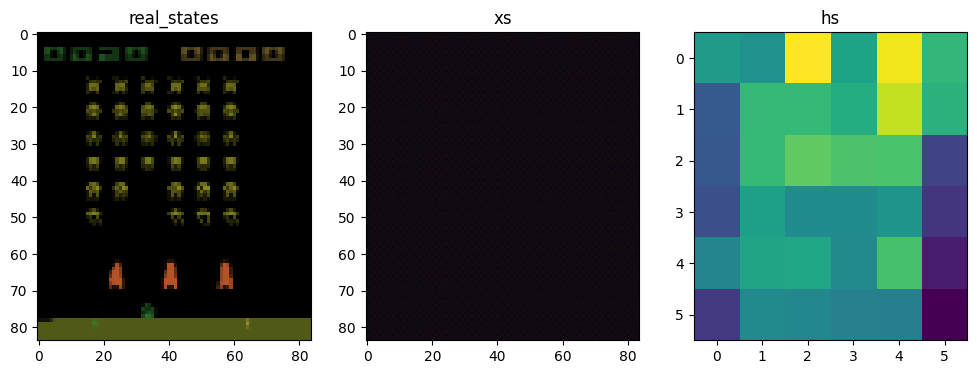

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# real_states의 형태를 조정하여 시각화
if "real_states" in data_0:
    # 첫 번째 배치, 첫 번째 프레임만 선택 (84x84 이미지)
    real_state_img = data_0["real_states"][0, 0]  # 첫 번째 배치의 첫 번째 프레임
    util.plot_raw_state(real_state_img, ax=axes[0], title="real_states")

# xs의 형태를 조정하여 시각화
if "xs" in data_0:
    # 첫 번째 배치, 첫 번째 프레임만 선택
    xs_img = data_0["xs"][0, 0]  # 첫 번째 배치의 첫 번째 프레임
    util.plot_raw_state(xs_img, ax=axes[1], title="xs")

# hs는 형태가 다르므로 직접 imshow 사용
if "hs" in data_0:
    # hs는 (2020, 32, 256, 6, 6) 형태이므로 첫 번째 채널만 시각화
    hs_img = data_0["hs"][0, 0, 1]  # 첫 번째 배치, 첫 번째 채널
    # plot_raw_state 대신 직접 imshow 사용
    axes[2].imshow(hs_img, cmap='viridis', interpolation="nearest", aspect="auto")
    axes[2].set_title("hs")

# 트리 표현 디코딩 및 출력
decoded_tree_rep = env.decode_tree_reps(data_0["tree_reps"])
print("=============TreeRep============")
for key, value in decoded_tree_rep.items():
    print(key, value[0])